<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 6: Clasificacion de Texto Multiclase con Pipelines de NLP</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> Construir y comparar varios clasificadores de texto <b>multiclase</b> usando <b>pipelines de scikit-learn</b> (TF-IDF + modelo), aplicandolos a un conjunto de noticias reales descargado de internet.
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Trabajaras con el dataset <b>BBC News</b>, que contiene 2,225 noticias clasificadas en <b>5 categorias</b>: <code>business</code>, <code>entertainment</code>, <code>politics</code>, <code>sport</code> y <code>tech</code>.</li>
<li>El dataset se <b>descarga directamente de la red</b> en la primera celda (no necesitas archivos locales).</li>
<li>Completa las celdas de cada sección reutilizando/modificando lo visto en el notebook de clase: <i>04_Clasificacion_de_Texto_Multiclase_Librerias</i>.</li>
<li>Entrena al menos <b>tres modelos</b> (Naive Bayes, Regresion Logistica y SVM lineal) usando <b>Pipeline</b> de scikit-learn.</li>
<li>Evalua con <b>precision, recall, F1-score</b> y una <b>matriz de confusion</b>.</li>
</ul>
</div>

<div style="border-left:4px solid #2e7d32; padding:10px; margin-top:10px; background:#f1f8e9;">
<b>Resultado esperado:</b> Una tabla comparativa de <i>accuracy</i> entre los tres modelos (se espera <b>&gt; 0.95</b> en el conjunto de prueba), una matriz de confusion del mejor modelo y predicciones correctas sobre noticias nuevas.
</div>


## 1. Carga del dataset desde la red

El dataset **BBC News** contiene 2,225 noticias en 5 categorias. Se distribuye como un unico
archivo CSV con dos columnas: `news` (el texto de la noticia) y `type` (la categoria).
Tras cargarlo las renombramos a `text` y `category`.

> **Fuente:** BBC Full-Text Dataset (D. Greene & P. Cunningham, 2006), mirror publico en GitHub.
> Se descarga con `pandas.read_csv` directamente desde la URL (usa `encoding='latin-1'`).

In [97]:
import pandas as pd

# Descarga directa del CSV (requiere conexion a internet la primera vez)
# Dataset BBC News: columnas 'news' (texto) y 'type' (categoria)
URL = "https://raw.githubusercontent.com/suraj-deshmukh/BBC-Dataset-News-Classification/master/dataset/dataset.csv"
df = pd.read_csv(URL, encoding="latin-1")

# Renombramos las columnas a nombres mas descriptivos
df = df.rename(columns={"news": "text", "type": "category"})

print(f"Dimensiones: {df.shape}")
print(f"Columnas   : {list(df.columns)}")
df.head()

Dimensiones: (2225, 2)
Columnas   : ['text', 'category']


,text,category
0,China had role in Yukos split-up\n \n China le...,business
1,Oil rebounds from weather effect\n \n Oil pric...,business
2,Indonesia 'declines debt freeze'\n \n Indonesi...,business
3,$1m payoff for former Shell boss\n \n Shell is...,business
4,US bank in $515m SEC settlement\n \n Five Bank...,business


## 2. Exploracion de datos (EDA)

Antes de modelar, analiza el dataset:

**Tareas:**
1. Cuenta cuantas noticias hay por categoria (`value_counts`).
2. Verifica si el dataset esta **balanceado**.
3. Calcula la **longitud promedio** (en palabras) de las noticias por categoria.
4. (Opcional) Grafica la distribucion de clases con un grafico de barras.

In [98]:
print("="*10,"1.-Cuantas noticias existen por categoria ","="*10)
cantidad_por_categoria = df['category'].value_counts()
print(cantidad_por_categoria)



========== 1.-Cuantas noticias existen por categoria  ==========
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


In [99]:
print("="*10,"2.-Veifica si el dataset esta balanceado ","="*10)
# porcentajes
print("="*10,"Porcentajes ","="*10)
porcentajes = df['category'].value_counts(normalize=True) * 100
print(porcentajes)

print(f"Categoría más frecuente: {cantidad_por_categoria.index[0]} con {cantidad_por_categoria.iloc[0]} textos")
print(f"Categoría menos frecuente: {cantidad_por_categoria.index[-1]} con {cantidad_por_categoria.iloc[-1]} textos")

========== 2.-Veifica si el dataset esta balanceado  ==========
========== Porcentajes  ==========
category
sport            22.966292
business         22.921348
politics         18.741573
tech             18.022472
entertainment    17.348315
Name: proportion, dtype: float64
Categoría más frecuente: sport con 511 textos
Categoría menos frecuente: entertainment con 386 textos


In [100]:
print("="*10,"3.-Calcula la **longitud promedio** (en palabras) de las noticias por categoria ","="*10)
df['num_palabras'] = df['text'].str.split().str.len()
estadisticas = df.groupby('category')['num_palabras'].agg([
    ('promedio', 'mean'),
    ('mediana', 'median'),
    ('minimo', 'min'),
    ('maximo', 'max'),
    ('desviacion', 'std'),
    ('count', 'count')
]).round(2)

print(estadisticas)

========== 3.-Calcula la **longitud promedio** (en palabras) de las noticias por categoria  ==========
               promedio  mediana  minimo  maximo  desviacion  count
category                                                           
business         328.88    297.0     140     891      135.92    510
entertainment    330.62    262.5     143    3482      261.80    386
politics         453.97    439.0      89    4432      300.12    417
sport            329.26    288.0     114    1662      187.96    511
tech             502.70    447.0     162    2969      239.85    401


C:\Users\iscer\AppData\Local\Temp\ipykernel_23268\16374192.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


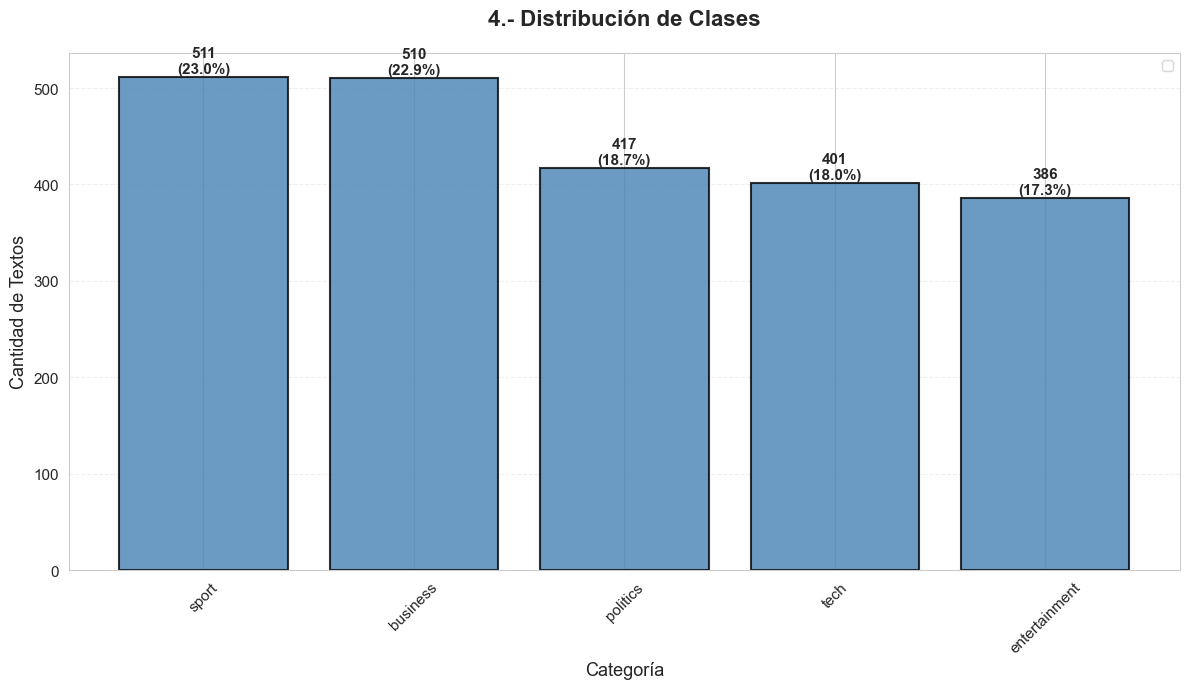

In [101]:
import matplotlib.pyplot as plt
import numpy as np

conteos = df['category'].value_counts()
porcentajes = (conteos / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(conteos.index, conteos.values, color='steelblue', 
              edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_title('4.- Distribución de Clases', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Categoría', fontsize=13)
ax.set_ylabel('Cantidad de Textos', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', labelsize=11)

for i, (bar, count, pct) in enumerate(zip(bars, conteos, porcentajes)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{count}\n({pct}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.legend()

plt.tight_layout()
plt.show()

## 3. Separacion train / test

**Tarea:** divide los datos en entrenamiento (80%) y prueba (20%) usando `train_test_split`
con `stratify` para mantener la proporcion de clases y `random_state=42` para reproducibilidad.

In [102]:
from sklearn.model_selection import train_test_split

textos =df['text']
etiquetas = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    textos, etiquetas, test_size=0.2, random_state=42, stratify=etiquetas
)
#test_size=0.2  para el 80 - 20
len(X_train)



1780

## 4. Construccion de los pipelines

Crea **tres pipelines** que combinen `TfidfVectorizer` con un clasificador distinto:

| Modelo | Clase de scikit-learn |
|--------|-----------------------|
| Naive Bayes | `MultinomialNB` |
| Regresion Logistica | `LogisticRegression` |
| SVM lineal | `LinearSVC` (envuelto en `CalibratedClassifierCV` si quieres probabilidades) |

> **Sugerencia de TF-IDF:** `ngram_range=(1,2)`, `max_features=10000`, `sublinear_tf=True`,
> y considera `stop_words='english'` (el texto esta en ingles).

In [103]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline

#  define un diccionario 'modelos' con los tres pipelines
modelos = { 'Naive Bayes': Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df = 1, max_features=1000, sublinear_tf = True)), ('clf', MultinomialNB(alpha=0.5))]),
            'Log. Reg.': Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df = 1, max_features=1000, sublinear_tf = True)), ('clr', LogisticRegression(C=5, max_iter=1000))]),
            'SVM': Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df = 1, max_features=1000, sublinear_tf = True)),('clsvm', CalibratedClassifierCV(LinearSVC(C = 1.0, max_iter = 2000)))])
}


## 5. Entrenamiento y evaluacion

**Tarea:** entrena cada modelo, calcula su `accuracy` en el conjunto de prueba y muestra el
`classification_report` (precision, recall, F1 por clase). Guarda los resultados para compararlos.

In [104]:
from sklearn.metrics import accuracy_score, classification_report

# itera sobre 'modelos', entrena (fit), predice y reporta metricas 
resultados = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train,y_train)
    y_pred = modelo.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    resultados[nombre] = {
        'accuracy': accuracy,
        'classification_report': report,
        'modelo':modelo
    }

    print("="*10,f"Modelo: {nombre}","="*10)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Classification Report:\n{report}")






========== Modelo: Naive Bayes ==========
Accuracy: 0.9573
Classification Report:
               precision    recall  f1-score   support

     business       0.91      0.94      0.93       102
entertainment       0.94      0.99      0.96        77
     politics       0.96      0.98      0.97        84
        sport       1.00      1.00      1.00       102
         tech       0.97      0.88      0.92        80

     accuracy                           0.96       445
    macro avg       0.96      0.96      0.96       445
 weighted avg       0.96      0.96      0.96       445

========== Modelo: Log. Reg. ==========
Accuracy: 0.9730
Classification Report:
               precision    recall  f1-score   support

     business       0.97      0.95      0.96       102
entertainment       0.96      0.99      0.97        77
     politics       0.98      0.99      0.98        84
        sport       0.98      1.00      0.99       102
         tech       0.97      0.94      0.96        80

     acc

## 6. Comparacion de modelos

**Tarea:** muestra una tabla (o grafico de barras) comparando el `accuracy` de los tres modelos
y selecciona el mejor.

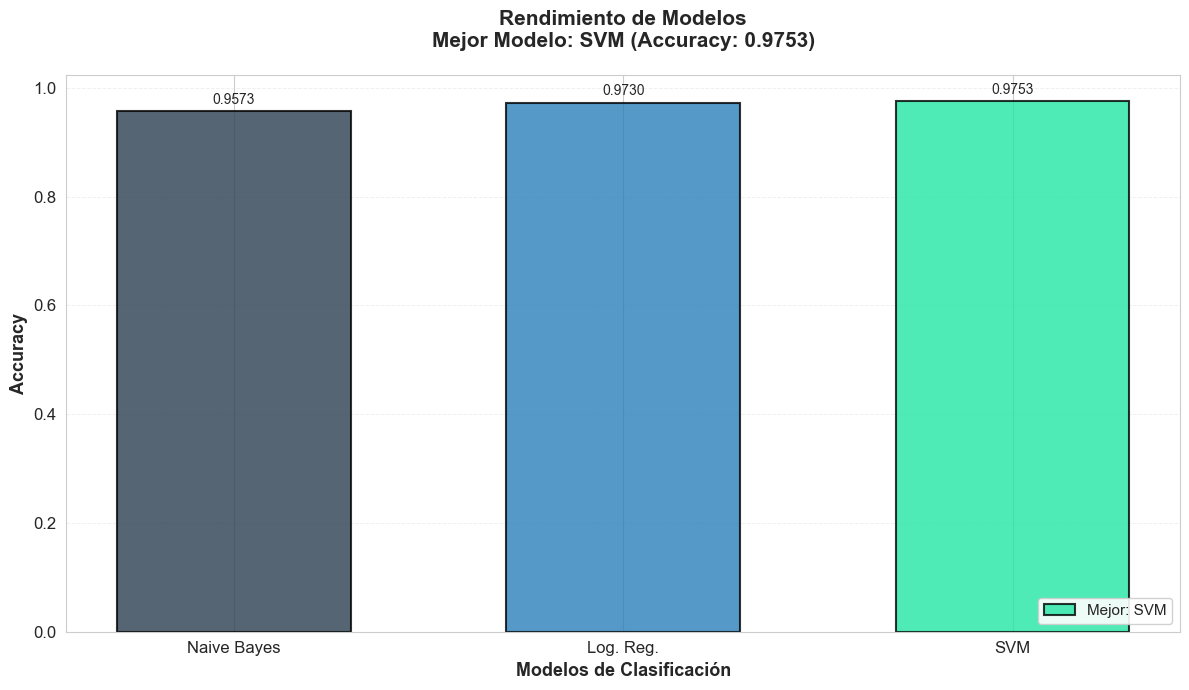

In [105]:
nombres= list(resultados.keys())
accuracies = [resultados[m]['accuracy'] for m in nombres]
mejor_idx = np.argmax(accuracies)
mejor_modelo = nombres[mejor_idx]
mejor_accuracy = accuracies[mejor_idx]

plt.figure(figsize=(12, 7))
barras = plt.bar(nombres, accuracies, 
                 color=['#2c3e50', '#2980b9', "#22e6a5"], 
                 alpha=0.8, 
                 edgecolor='black', 
                 linewidth=1.5,
                 width=0.6)

for i, (barra, acc) in enumerate(zip(barras, accuracies)):
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 0.008,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=10)
    


plt.xlabel('Modelos de Clasificación', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy', fontsize=13, fontweight='bold')
plt.title(f'Rendimiento de Modelos\n'
          f'Mejor Modelo: {mejor_modelo} (Accuracy: {mejor_accuracy:.4f})', 
          fontsize=15, fontweight='bold', pad=20)

plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend([barras[mejor_idx]], [f'Mejor: {mejor_modelo}'], 
           loc='lower right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()



## 7. Matriz de confusion del mejor modelo

**Tarea:** genera la **matriz de confusion** del mejor modelo con
`ConfusionMatrixDisplay.from_estimator` (o `confusion_matrix` + `seaborn.heatmap`) e interpreta
que categorias se confunden mas entre si.

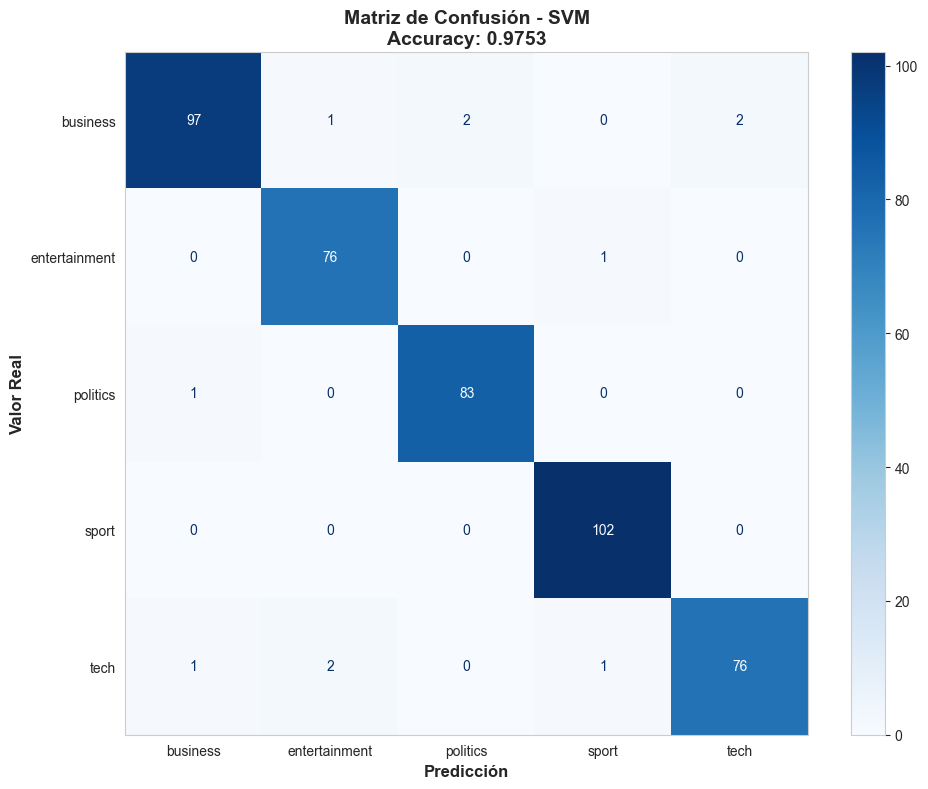

In [106]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

modelo = resultados[mejor_modelo]['modelo']
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_estimator(
    modelo,                 # El modelo entrenado
    X_test,                 # Datos de prueba
    y_test,                 # Etiquetas reales
    display_labels=None,    # Usar las etiquetas originales
    cmap='Blues',           # Mapa de colores 
    normalize=None,         # Mostrar conteos absolutos 
    values_format='d',      # Formato de números enteros
    ax=ax                   # Eje donde dibujar
)

ax.set_title(f'Matriz de Confusión - {mejor_modelo}\nAccuracy: {mejor_accuracy:.4f}', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicción', fontsize=12, fontweight='bold')
ax.set_ylabel('Valor Real', fontsize=12, fontweight='bold')

ax.tick_params(axis='both', labelsize=10)
ax.grid(False)

plt.tight_layout()
plt.show()



In [107]:
print("="*10,"Interpreta la matriz de confusion ","="*10)

print("SPORT se clasifico al 100%, 0 errores")
print("POLITICS se clasifico igual muy alto 83/84, 1 error")
print("ENTRETAINMENT se clasifico igual muy alto 76/77, 1 error")
print("BUSINESS se clasifico  97/102, 5 errores")
print("TECH se clasifico  76/80, 4 errores")
print("Business es quien mas tiene casos de error con Politics y Teach, puede ser porque las palabras que se utilizan son muy similatres en estas 3 categorias")


========== Interpreta la matriz de confusion  ==========
SPORT se clasifico al 100%, 0 errores
POLITICS se clasifico igual muy alto 83/84, 1 error
ENTRETAINMENT se clasifico igual muy alto 76/77, 1 error
BUSINESS se clasifico  97/102, 5 errores
TECH se clasifico  76/80, 4 errores
Business es quien mas tiene casos de error con Politics y Teach, puede ser porque las palabras que se utilizan son muy similatres en estas 3 categorias


## 8. Prediccion sobre noticias nuevas

**Tarea:** usa el mejor modelo para clasificar al menos **4 titulares o noticias nuevas**
(puedes inventarlos o copiarlos de un periodico en ingles) y muestra la categoria predicha con
su nivel de confianza.

In [108]:
noticias_nuevas = [
    "The central bank raised interest rates to control rising inflation.",
    "The team secured a dramatic victory in the championship final last night.",
    "The new smartphone features a faster chip and an improved camera system.",
    "The prime minister announced a new policy during the parliamentary session.",
]
print("="*10,"Predicciones nuevas noticias ","="*10)
for noticia in noticias_nuevas:
    category = modelo.predict([noticia])[0]
    probs = modelo.predict_proba([noticia])[0]

    print(f'Noticia: {noticia}...')
    print(f'Categoria: {category}')
    print(f'Nivel de confianza:: {max(probs)}')



========== Predicciones nuevas noticias  ==========
Noticia: The central bank raised interest rates to control rising inflation....
Categoria: business
Nivel de confianza:: 0.9641055359856991
Noticia: The team secured a dramatic victory in the championship final last night....
Categoria: sport
Nivel de confianza:: 0.9052314243537667
Noticia: The new smartphone features a faster chip and an improved camera system....
Categoria: sport
Nivel de confianza:: 0.3570369703701464
Noticia: The prime minister announced a new policy during the parliamentary session....
Categoria: politics
Nivel de confianza:: 0.8143349307174382
